import all the libraries

In [173]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

load the dataset

In [174]:
df=pd.read_csv("retail_sales_dataset.csv")
df.describe()

,age,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,customer_satisfaction,days_to_ship
count,4150.000000,4170.000000,4280.000000,4143.000000,4.280000e+03,4.280000e+03,4280.000000,3932.000000,4180.000000
mean,35.335181,7.379856,10621.154428,0.202085,6.235864e+04,1.168713e+04,63.358836,3.016531,5.620335
std,35.709382,43.578352,17323.704016,0.118095,3.166998e+05,5.287522e+04,18.312281,1.413127,4.178663
min,-7.000000,-1.000000,50.260000,0.000000,3.945000e+01,1.560000e+00,-4.290000,1.000000,-1.000000
25%,26.000000,3.000000,672.222500,0.100000,2.462165e+03,7.018225e+02,50.817500,2.000000,3.000000
50%,34.000000,5.000000,2228.435000,0.210000,9.548075e+03,3.128005e+03,63.465000,3.000000,6.000000
75%,42.000000,8.000000,12717.435000,0.310000,5.006964e+04,1.040372e+04,75.650000,4.000000,8.000000
max,999.000000,999.000000,79957.920000,0.400000,1.736031e+07,2.445648e+06,133.350000,5.000000,100.000000


In [175]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4310 entries, 0 to 4309
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               4280 non-null   str    
 1   order_date             4280 non-null   str    
 2   customer_id            4280 non-null   str    
 3   customer_name          4280 non-null   str    
 4   age                    4150 non-null   float64
 5   gender                 4280 non-null   str    
 6   region                 4280 non-null   str    
 7   city                   4280 non-null   str    
 8   product_category       4280 non-null   str    
 9   product_name           4280 non-null   str    
 10  quantity               4170 non-null   float64
 11  unit_price             4280 non-null   float64
 12  discount_pct           4143 non-null   float64
 13  sales_amount           4280 non-null   float64
 14  profit                 4280 non-null   float64
 15  shipping_cost  

In [176]:
df.shape


(4310, 21)

In [177]:
df.isna().sum()

order_id                  30
order_date                30
customer_id               30
customer_name             30
age                      160
gender                    30
region                    30
city                      30
product_category          30
product_name              30
quantity                 140
unit_price                30
discount_pct             167
sales_amount              30
profit                    30
shipping_cost             30
payment_method            30
customer_satisfaction    378
return_flag               30
order_status              30
days_to_ship             130
dtype: int64

In [178]:
df['age']=df['age'].fillna(df['age'].median())
print(df['age'].isnull().sum())

0


In [179]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4310 entries, 0 to 4309
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               4280 non-null   str    
 1   order_date             4280 non-null   str    
 2   customer_id            4280 non-null   str    
 3   customer_name          4280 non-null   str    
 4   age                    4310 non-null   float64
 5   gender                 4280 non-null   str    
 6   region                 4280 non-null   str    
 7   city                   4280 non-null   str    
 8   product_category       4280 non-null   str    
 9   product_name           4280 non-null   str    
 10  quantity               4170 non-null   float64
 11  unit_price             4280 non-null   float64
 12  discount_pct           4143 non-null   float64
 13  sales_amount           4280 non-null   float64
 14  profit                 4280 non-null   float64
 15  shipping_cost  

In [180]:
df['quantity']=df['quantity'].fillna(df['quantity'].median())

In [181]:
df['city']=df['city'].fillna('Not Applicable')
df = df.dropna(subset=['days_to_ship'])

In [182]:
df.isnull().sum()


order_id                   0
order_date                 0
customer_id                0
customer_name              0
age                        0
gender                     0
region                     0
city                       0
product_category           0
product_name               0
quantity                   0
unit_price                 0
discount_pct             133
sales_amount               0
profit                     0
shipping_cost              0
payment_method             0
customer_satisfaction    341
return_flag                0
order_status               0
days_to_ship               0
dtype: int64

In [183]:
df['customer_satisfaction']=df['customer_satisfaction'].fillna(df['customer_satisfaction'].median())

In [184]:
df['discount_pct']=df['discount_pct'].fillna(df['discount_pct'].median())

In [185]:
df.isnull().sum()

order_id                 0
order_date               0
customer_id              0
customer_name            0
age                      0
gender                   0
region                   0
city                     0
product_category         0
product_name             0
quantity                 0
unit_price               0
discount_pct             0
sales_amount             0
profit                   0
shipping_cost            0
payment_method           0
customer_satisfaction    0
return_flag              0
order_status             0
days_to_ship             0
dtype: int64

In [186]:
print("_____Statistical Summary____")
print(df[['sales_amount','profit','quantity']].describe())

_____Statistical Summary____
       sales_amount        profit     quantity
count  4.180000e+03  4.180000e+03  4180.000000
mean   6.244472e+04  1.171093e+04     7.371292
std    3.198836e+05  5.342154e+04    43.523980
min    3.945000e+01  1.560000e+00    -1.000000
25%    2.462165e+03  6.993875e+02     3.000000
50%    9.638945e+03  3.140870e+03     5.000000
75%    5.006964e+04  1.043355e+04     8.000000
max    1.736031e+07  2.445648e+06   999.000000


In [187]:
print("____Region summary______")
categoryregion_summay=df.groupby('region').agg({
    'sales_amount':['sum','mean'],
    'profit':['sum','mean']
}).round(2)
print(categoryregion_summay)

____Region summary______
        sales_amount                 profit          
                 sum      mean          sum      mean
region                                               
Central  39762655.57  51043.20   8123308.74  10427.87
East     48913464.01  58931.88   8759710.39  10553.87
North    52147466.09  61712.98  10127211.91  11984.87
South    73056784.06  84851.08  13238617.39  15375.86
West     47138557.78  54495.44   8702844.12  10061.09


In [188]:
df['order_date'] = pd.to_datetime(
    df['order_date'],
    errors='coerce',
        dayfirst=True
)

C:\Users\zaima\AppData\Local\Temp\ipykernel_15844\1500501135.py:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['order_date'] = pd.to_datetime(


In [189]:
print(df['order_date'].dtype)

datetime64[us]


In [190]:
df = df.dropna(subset=['order_date'])


In [191]:
df['Month']=df['order_date'].dt.month
df['MonthName']=df['order_date'].dt.month_name()

In [192]:
montly_sales=df.groupby(['Month','MonthName']).agg({
    'sales_amount':'sum',
    'profit':'sum',
    'quantity':'sum'
}).reset_index()
montly_sales=montly_sales.sort_values('Month')
print(montly_sales)

    Month  MonthName  sales_amount      profit  quantity
0       1    January   32054733.30  5592741.55    3670.0
1       2   February   15996007.90  3194132.16    2787.0
2       3      March   17116551.07  3001490.16    1701.0
3       4      April   26247573.74  5127652.48    2695.0
4       5        May   21601478.74  4066864.61    1843.0
5       6       June   22596231.68  4102893.07    1650.0
6       7       July   25853075.45  4641501.78    2922.0
7       8     August   25563586.92  5442132.46    3000.0
8       9  September   17711642.00  3380272.83    1670.0
9      10    October   14310338.19  2877305.39    1804.0
10     11   November   13244693.75  2219795.48    2747.0
11     12   December   13219503.96  2592707.57    2860.0


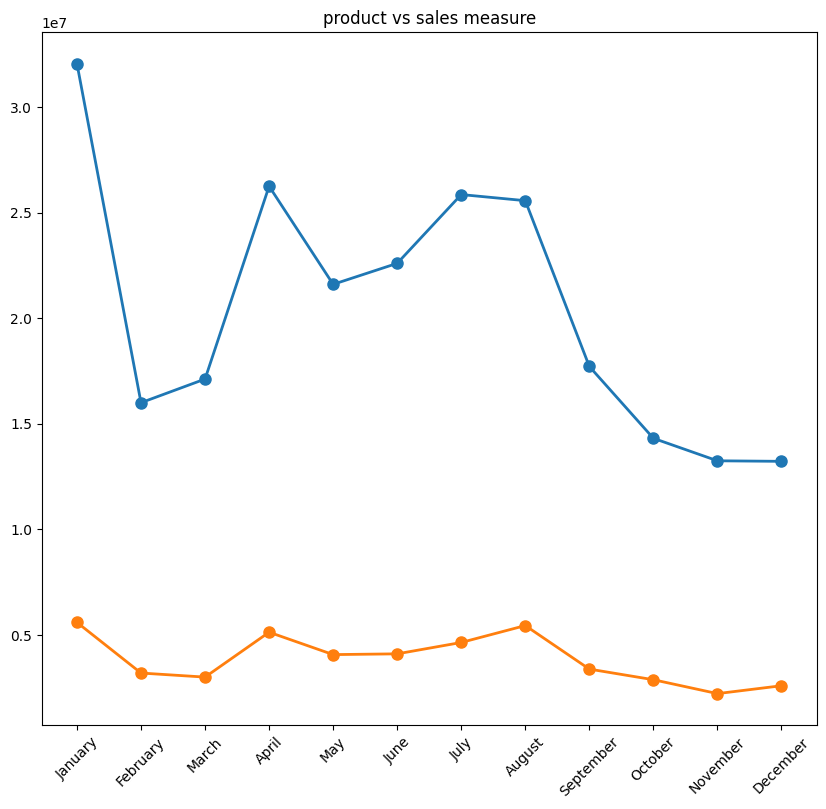

In [193]:
plt.figure(figsize=(10,9))
plt.plot(montly_sales['MonthName'],montly_sales['sales_amount'],marker='o',linewidth=2,markersize=8,label="salesamount")
plt.plot(montly_sales['MonthName'],montly_sales['profit'],marker='o',linewidth=2,markersize=8,label="Profit")
plt.title("product vs sales measure")
plt.xticks(rotation=45)
plt.show()


In [194]:
print("------Categorical analysis-----------")
categorical_analysis=df.groupby('product_category').agg({
    'sales_amount':'sum',
    'profit':'sum',
    'quantity':'sum'
}).sort_values('sales_amount',ascending=False)
print(categorical_analysis)

------Categorical analysis-----------
                  sales_amount       profit  quantity
product_category                                     
Electronics       1.429524e+08  17550685.37    4086.0
Furniture         5.316503e+07  15016196.78    3102.0
Sports            3.018847e+07   6667954.88    4043.0
Clothing          1.105957e+07   3981334.74    5097.0
Beauty            3.666843e+06   1646340.00    3087.0
Books             3.518854e+06   1301335.38    5756.0
Groceries         9.642109e+05     75642.39    4178.0


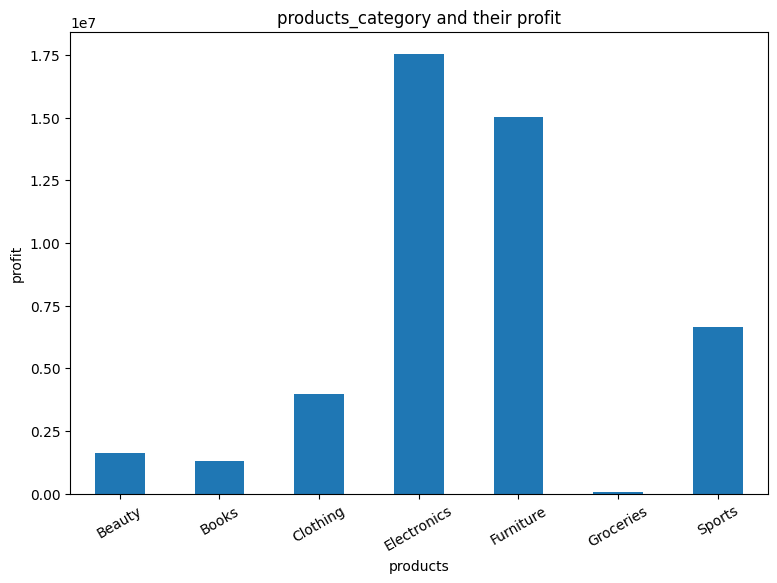

In [195]:
gropued=df.groupby('product_category')['profit'].sum()
gropued.plot(kind='bar',figsize=(9,6))
plt.title("products_category and their profit")
plt.xlabel("products")
plt.ylabel("profit")
plt.xticks(rotation=30)
plt.show()

In [197]:
print("____Region summary______")
categoryregion_summay=df.groupby('region').agg({
    'sales_amount':['sum','mean'],
    'profit':['sum','mean']
}).round(2)
print(categoryregion_summay)

____Region summary______
        sales_amount                 profit          
                 sum      mean          sum      mean
region                                               
Central  36812171.41  50496.81   7741237.05  10618.98
East     44420934.17  57839.76   7977961.68  10387.97
North    48338647.02  60956.68   9445546.22  11911.16
South    71791947.23  87658.06  12920120.76  15775.48
West     44151716.87  54441.08   8154623.83  10055.02


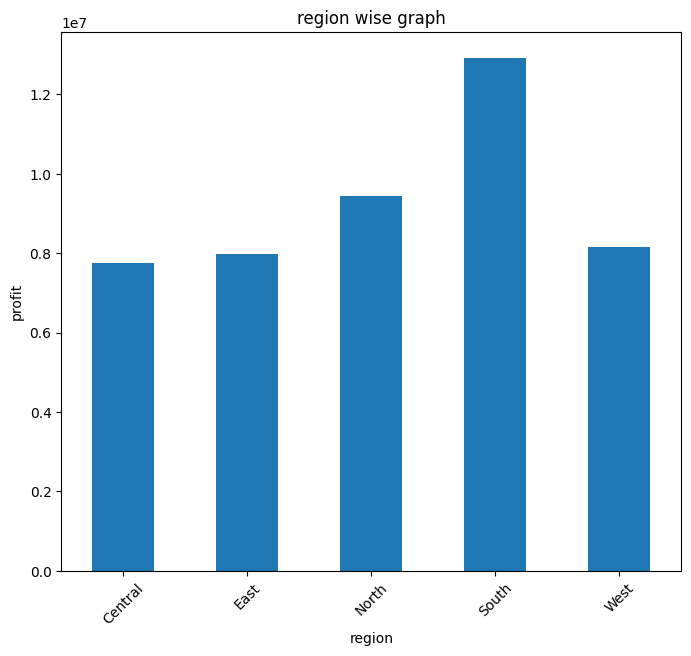

In [200]:
group=df.groupby('region')['profit'].sum()
group.plot(kind='bar',figsize=(8,7))
plt.title("region wise graph")
plt.xlabel("region")
plt.ylabel("profit")
plt.xticks(rotation=45)
plt.show()

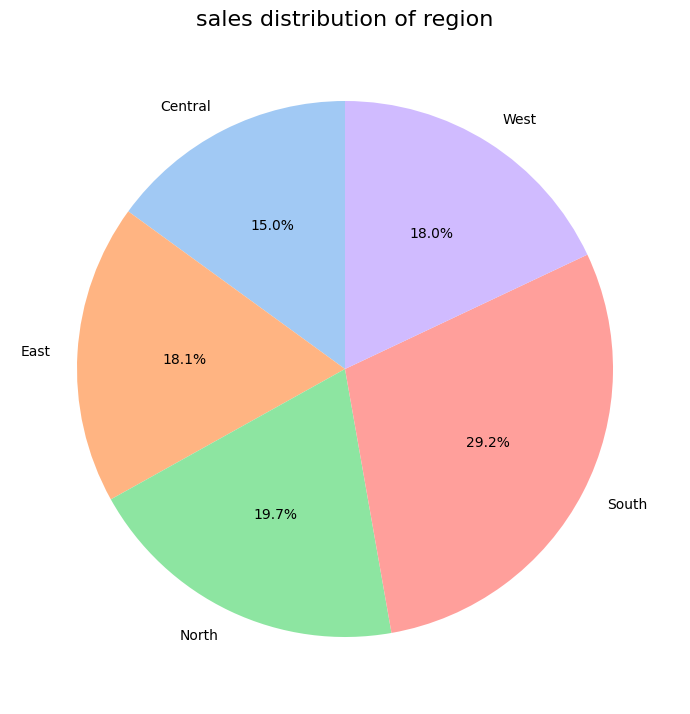

In [201]:
plt.figure(figsize=(7,8))
regional_data=df.groupby('region')['sales_amount'].sum()
plt.pie(regional_data,labels=regional_data.index,autopct='%1.1f%%',startangle=90,colors=sns.color_palette("pastel"))
plt.title("sales distribution of region",fontsize=16)
plt.tight_layout()
plt.show()

Now, calculate the correlation matrices

In [204]:
numerical_df=df[['sales_amount','quantity','profit']]
correlation_matrix=numerical_df.corr()
print("correlation_matrix",correlation_matrix)

correlation_matrix               sales_amount  quantity    profit
sales_amount      1.000000  0.542274  0.949313
quantity          0.542274  1.000000  0.663433
profit            0.949313  0.663433  1.000000


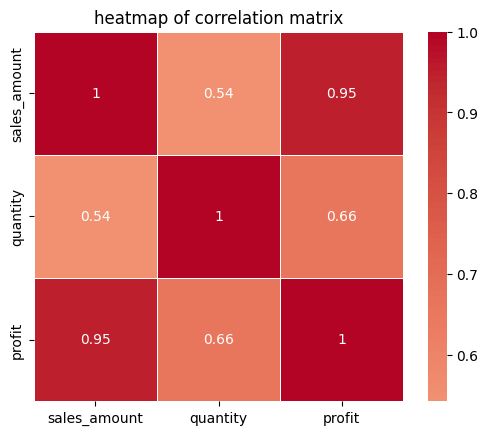

In [206]:
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)
plt.title("heatmap of correlation matrix")
plt.show()


----------charts visualization Dashboard--------------------


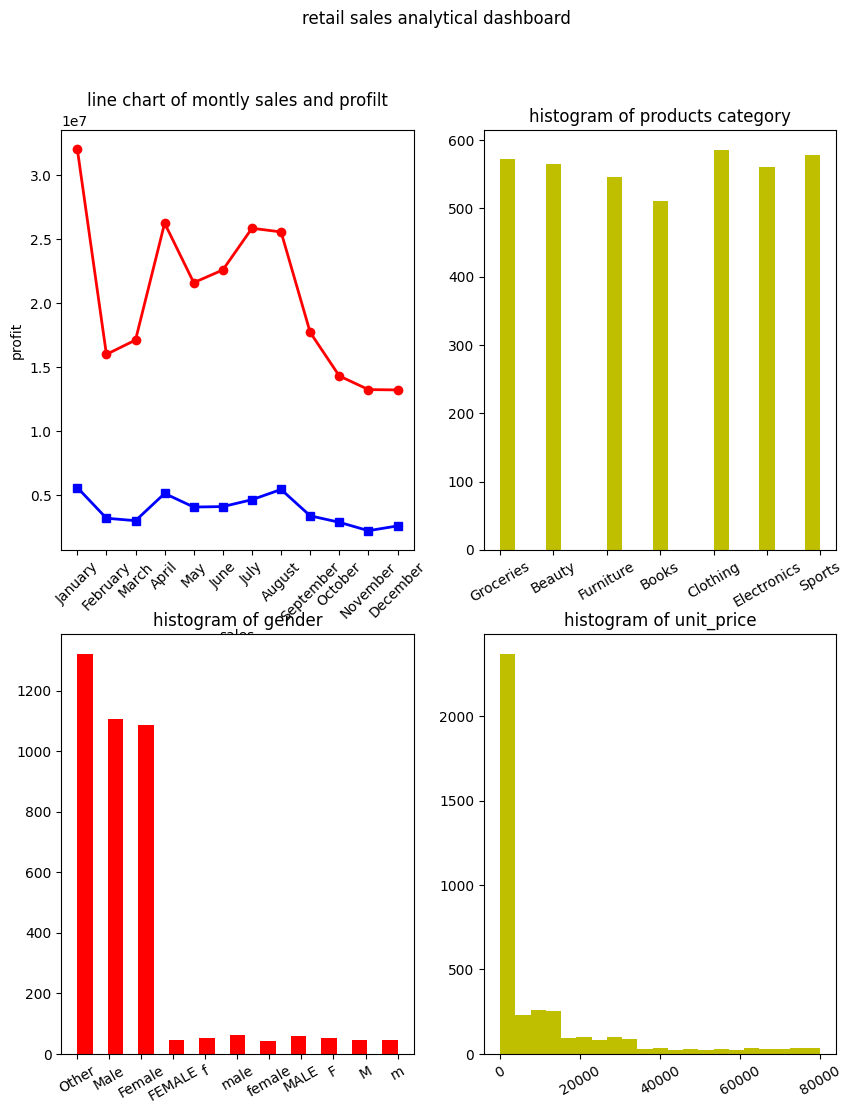

In [218]:
print("----------charts visualization Dashboard--------------------")
fig,axs=plt.subplots(2,2, figsize=(10,12))
fig.suptitle("retail sales analytical dashboard")
axs[0,0].plot(montly_sales['MonthName'],montly_sales['sales_amount'],linewidth=2
              ,color='red',marker='o')
axs[0,0].plot(montly_sales['MonthName'],montly_sales['profit'],linewidth=2,color='blue',marker='s')
axs[0,0].set_title("line chart of montly sales and profilt")
axs[0,0].set_xlabel("sales")
axs[0,0].set_ylabel("profit")
axs[0,0].tick_params(axis='x',rotation=45)

axs[0,1].hist(df['product_category'],bins=21,color='y')
axs[0,1].set_title("histogram of products category")
axs[0,1].tick_params(axis='x',rotation=30)

axs[1,0].hist(df['gender'],bins=21,color='r')
axs[1,0].set_title("histogram of gender")
axs[1,0].tick_params(axis='x',rotation=30)

axs[1,1].hist(df['unit_price'],bins=21,color='y')
axs[1,1].set_title("histogram of unit_price")
axs[1,1].tick_params(axis='x',rotation=30)

